In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import numpy as np
import pandas as pd
from wordcloud import WordCloud
from collections import Counter

C:\Users\kalmy\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Загрузка датасета AG News...")
dataset = load_dataset("ag_news")
train_texts = dataset['train']['text']

Загрузка датасета AG News...


Подсчет длины текстов

=== Статистика по длине текстов (в словах) ===
Количество текстов: 120,000
Средняя длина: 37.85
Медианная длина: 37.00
Минимальная длина: 8
Максимальная длина: 177
Стандартное отклонение: 10.09

=== Квантили распределения ===
50% текстов короче 37 слов
75% текстов короче 43 слов
90% текстов короче 48 слов
95% текстов короче 53 слов
99% текстов короче 70 слов

Сколько текстов объемом до: 
До 30 слов: 20.4%
30-50 слов: 72.8%
50-100 слов: 6.7%
Более 100 слов: 0.2%


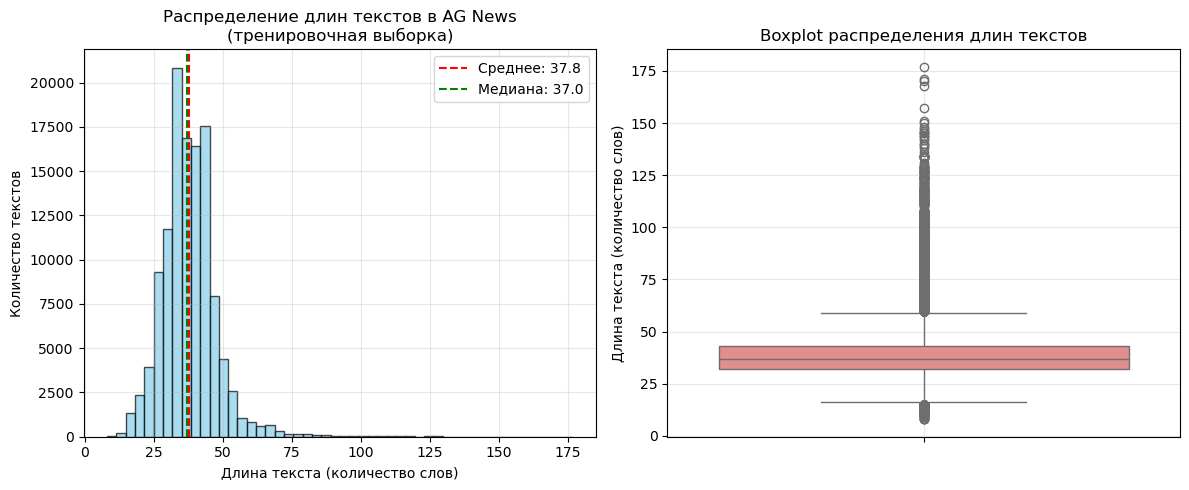

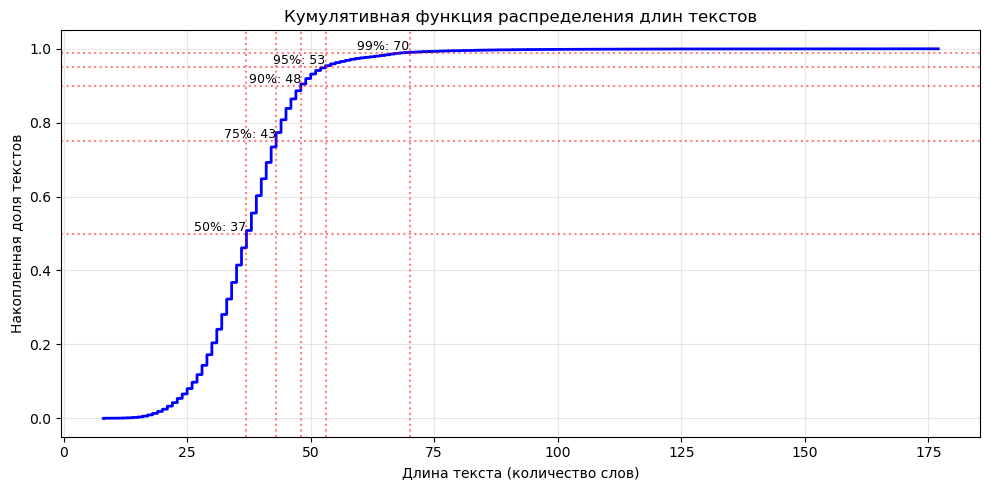


=== Рекомендация для настройки модели ===
95% текстов короче 53 слов
Рекомендуемое значение max_len: 53
Текущее значение max_len (если 128): Избыточно


In [3]:
def count_words(text):
    return len(text.split())

print("Подсчет длины текстов")
text_lengths = [count_words(text) for text in train_texts]

lengths_array = np.array(text_lengths)
print(f"\n=== Статистика по длине текстов (в словах) ===")
print(f"Количество текстов: {len(text_lengths):,}")
print(f"Средняя длина: {np.mean(lengths_array):.2f}")
print(f"Медианная длина: {np.median(lengths_array):.2f}")
print(f"Минимальная длина: {np.min(lengths_array)}")
print(f"Максимальная длина: {np.max(lengths_array)}")
print(f"Стандартное отклонение: {np.std(lengths_array):.2f}")

# Квантили
print(f"\n=== Квантили распределения ===")
for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"{q*100:.0f}% текстов короче {np.percentile(lengths_array, q*100):.0f} слов")

print(f"\nСколько текстов объемом до: ")
print(f"До 30 слов: {sum(1 for l in text_lengths if l <= 30)/len(text_lengths)*100:.1f}%")
print(f"30-50 слов: {sum(1 for l in text_lengths if 30 < l <= 50)/len(text_lengths)*100:.1f}%")
print(f"50-100 слов: {sum(1 for l in text_lengths if 50 < l <= 100)/len(text_lengths)*100:.1f}%")
print(f"Более 100 слов: {sum(1 for l in text_lengths if l > 100)/len(text_lengths)*100:.1f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Длина текста (количество слов)')
plt.ylabel('Количество текстов')
plt.title('Распределение длин текстов в AG News\n(тренировочная выборка)')
plt.axvline(np.mean(lengths_array), color='red', linestyle='--', label=f'Среднее: {np.mean(lengths_array):.1f}')
plt.axvline(np.median(lengths_array), color='green', linestyle='--', label=f'Медиана: {np.median(lengths_array):.1f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=text_lengths, color='lightcoral')
plt.ylabel('Длина текста (количество слов)')
plt.title('Boxplot распределения длин текстов')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sorted_lengths = np.sort(text_lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
plt.plot(sorted_lengths, cumulative, 'b-', linewidth=2)
plt.xlabel('Длина текста (количество слов)')
plt.ylabel('Накопленная доля текстов')
plt.title('Кумулятивная функция распределения длин текстов')
plt.grid(True, alpha=0.3)

for percentile in [50, 75, 90, 95, 99]:
    value = np.percentile(sorted_lengths, percentile)
    plt.axhline(y=percentile/100, color='red', linestyle=':', alpha=0.5)
    plt.axvline(x=value, color='red', linestyle=':', alpha=0.5)
    plt.text(value, percentile/100, f'{percentile}%: {value:.0f}', 
             fontsize=9, ha='right', va='bottom')

plt.tight_layout()
plt.show()

recommended_len = int(np.percentile(lengths_array, 95))
print(f"\n=== Рекомендация для настройки модели ===")
print(f"95% текстов короче {recommended_len} слов")
print(f"Рекомендуемое значение max_len: {recommended_len}")
print(f"Текущее значение max_len (если 128): {'Избыточно' if 128 > recommended_len else 'Недостаточно'}")

## Строим облака слов

Дополнительно исключим из текстов наименее значимые служебные слова, иначе весь анализ сосредоточится на них

In [4]:
df_train = pd.DataFrame({
    'text': dataset['train']['text'],
    'label': dataset['train']['label']
})

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
stop_words = {'a', 'an', 's', 'as', 'its', 'the', 'and', 'of', 'to', 'in', 'for', 'on', 'with', 
                  'by', 'at', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
                  'this', 'that', 'these', 'those', 'it', 'they', 'we', 'you',
                  'he', 'she', 'it', 'them', 'their', 'our', 'your'}

def simple_tokenize(text, fix_html = False):
    import re
    text = text.lower()
    if fix_html:
        text = re.sub(r'#[a-zA-Z0-9]+;', ' ', text) # убрать ошибки html
    #text = re.sub(r'\b\d+(?:\.\d+)?\b', '<NUM>', text) # заменить числа на единый токен <NUM>
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

In [5]:
def get_class_word_info(df_train, class_names, fix_html=False):
    class_vocab = {}
    class_word_counts = {}
    for label_id, class_name in enumerate(class_names):
        class_texts = df_train[df_train['label'] == label_id]['text'].tolist()
        
        all_words = []
        for text in class_texts:
            tokens = simple_tokenize(text, fix_html)
            all_words.extend(tokens)
        
        word_counts = Counter(all_words)
        class_word_counts[class_name] = word_counts
        class_vocab[class_name] = word_counts.most_common(20)
        
        print(f"\n{class_name}")
        print(f"  Уникальных слов: {len(word_counts)}")
        print(f"  Топ-10 слов: {', '.join([w for w, _ in word_counts.most_common(10)])}")
    return class_vocab, class_word_counts

In [6]:
def print_words_clouds(class_word_counts):
    class_colors = {
        'World': 'Blues',
        'Sports': 'Greens', 
        'Business': 'Reds',
        'Sci/Tech': 'Purples'
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    for idx, (class_name, word_counts) in enumerate(class_word_counts.items()):
        word_freq = dict(word_counts)
    
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color='white',
            colormap=class_colors.get(class_name, 'viridis'),
            max_words=100,
            prefer_horizontal=0.7,
            relative_scaling=0.5
        ).generate_from_frequencies(word_freq)
    
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'{class_name}', fontsize=16, fontweight='bold', pad=20)

    plt.suptitle('Облака слов для каждого класса новостей AG News', fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


World
  Уникальных слов: 29949
  Топ-10 слов: 39, said, iraq, ap, reuters, his, has, after, president, us

Sports
  Уникальных слов: 31238
  Топ-10 слов: 39, his, ap, after, game, first, new, over, has, season

Business
  Уникальных слов: 28289
  Топ-10 слов: 39, reuters, said, new, oil, us, gt, lt, stocks, inc

Sci/Tech
  Уникальных слов: 33543
  Топ-10 слов: 39, new, has, microsoft, will, gt, lt, ap, said, software


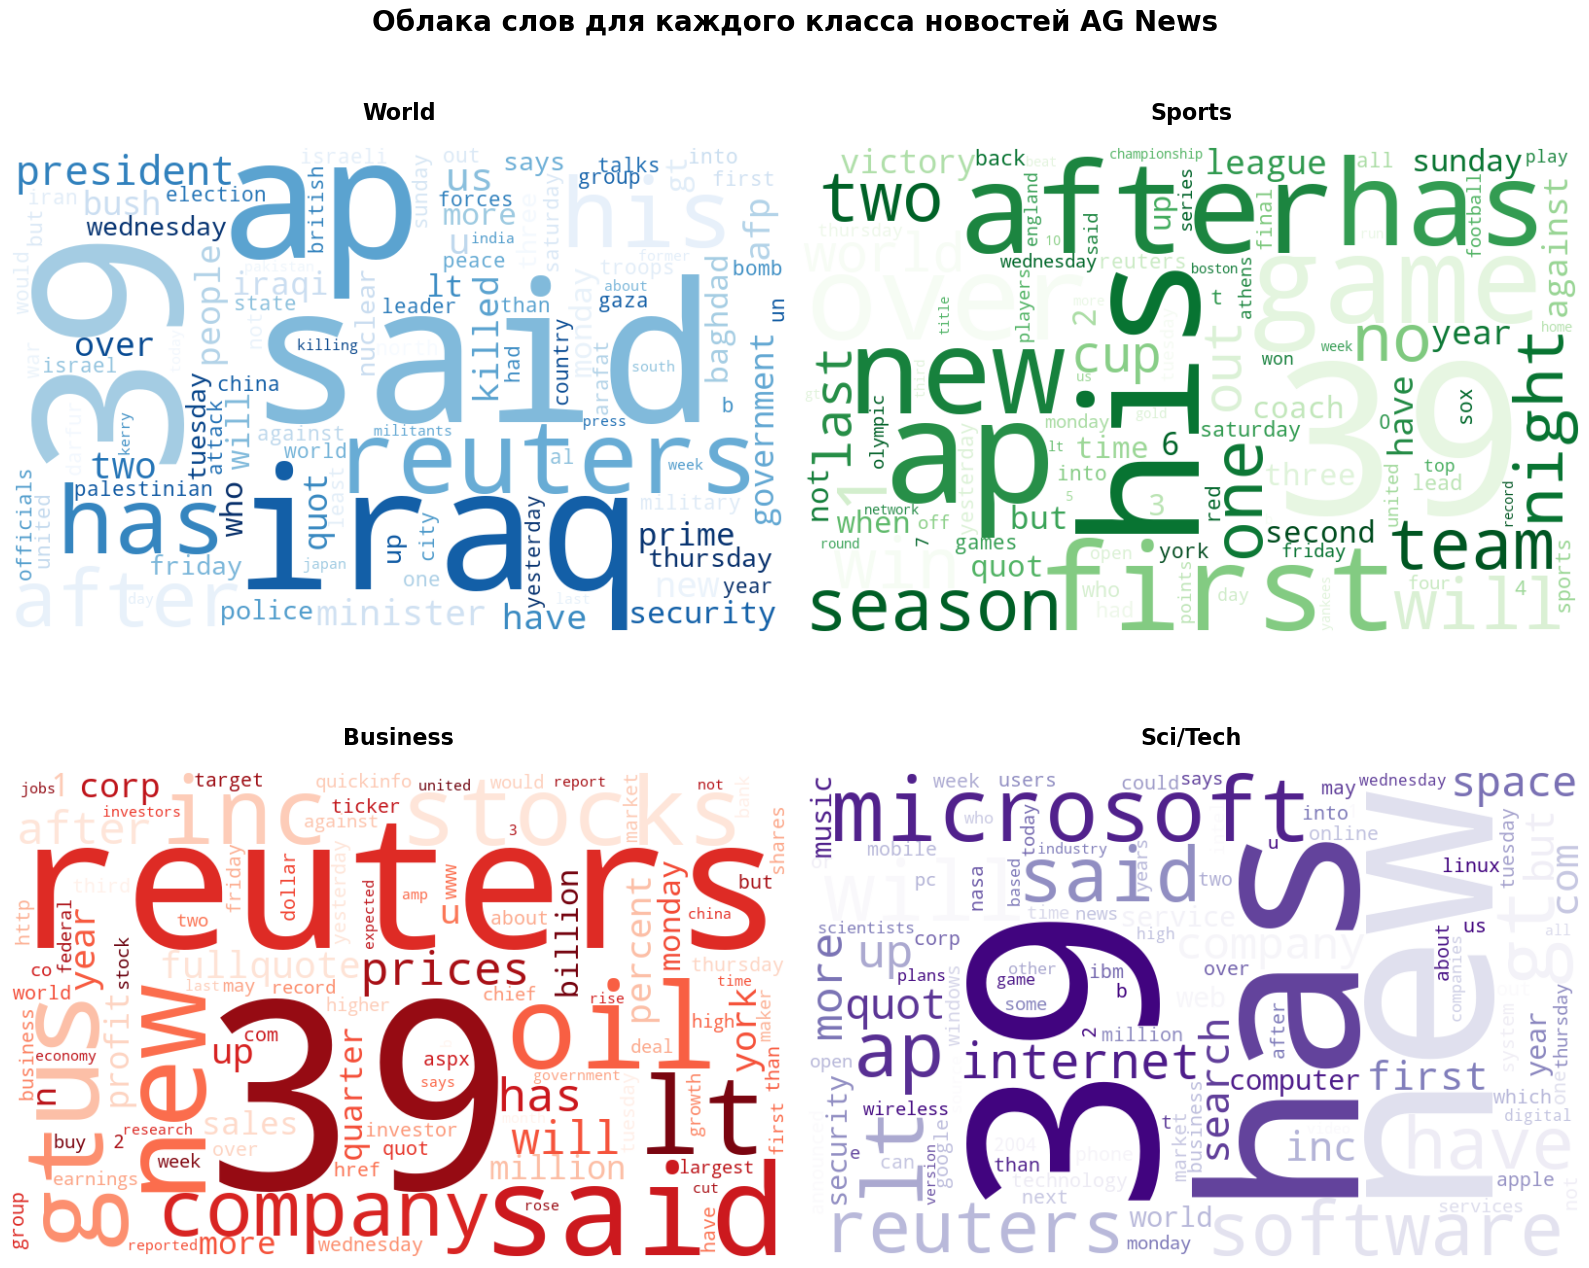

In [7]:
class_vocab, class_word_counts = get_class_word_info(df_train, class_names)
print_words_clouds(class_word_counts)

Меня удивило почему число 39 такое популярное во всех классах, но интернет говорит что &#39 это html-код кавычек, т.е. в тексте осталось множество аретфактов html (gt, lt туда же)  
**upd**: проверила, действительно в тексте вместо апострофа много где можно встретить конструкцию #39;  

Попробуем убрать html коды и посмотрим на распределение слов:


World
  Уникальных слов: 29945
  Топ-10 слов: said, iraq, ap, reuters, his, has, after, president, us, two

Sports
  Уникальных слов: 31236
  Топ-10 слов: his, ap, after, game, first, new, over, has, season, will

Business
  Уникальных слов: 28288
  Топ-10 слов: reuters, said, new, oil, us, gt, lt, stocks, inc, company

Sci/Tech
  Уникальных слов: 33531
  Топ-10 слов: new, has, microsoft, will, gt, lt, ap, said, software, reuters


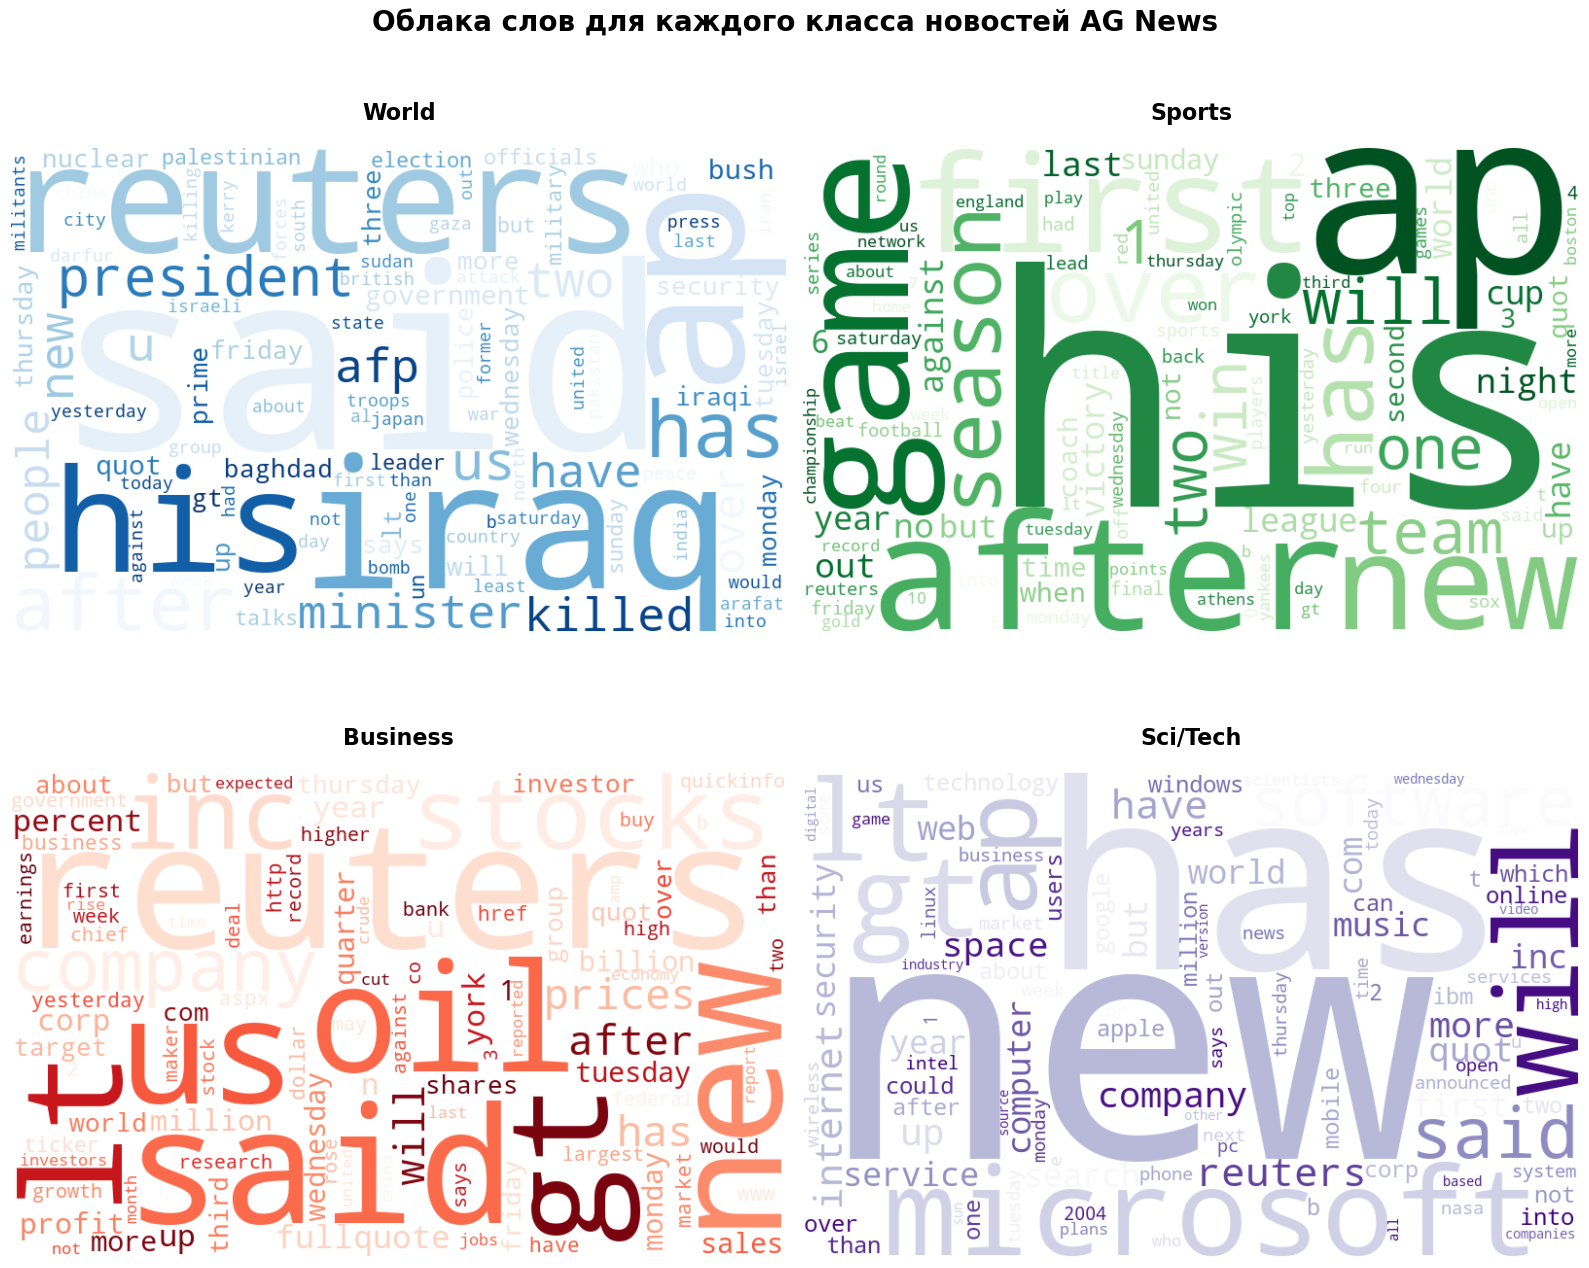

In [8]:
class_vocab, class_word_counts = get_class_word_info(df_train, class_names, fix_html=True)
print_words_clouds(class_word_counts)

Дополнительно посмотрим какие уникальные слова свойственны каждому из классов:

In [9]:
all_words_class = {}
for class_name, word_counts in class_word_counts.items():
    all_words_class[class_name] = set(word_counts.keys())

for class_name in class_names:
    other_classes = [c for c in class_names if c != class_name]
    other_words = set()
    for other in other_classes:
        other_words.update(all_words_class[other])
    
    unique_words = all_words_class[class_name] - other_words
    unique_with_freq = [(w, class_word_counts[class_name][w]) for w in unique_words if w in class_word_counts[class_name]]
    unique_with_freq.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n{class_name}:")
    if unique_with_freq[:10]:
        for word, freq in unique_with_freq[:10]:
            print(f"  {word} (встречается {freq} раз)")
    else:
        print("  Нет уникальных слов в топе")


World:
  sadr (встречается 468 раз)
  hamas (встречается 439 раз)
  falluja (встречается 366 раз)
  zarqawi (встречается 246 раз)
  qaida (встречается 222 раз)
  mosul (встречается 217 раз)
  sunni (встречается 213 раз)
  abbas (встречается 174 раз)
  peacekeepers (встречается 169 раз)
  khartoum (встречается 166 раз)

Sports:
  preseason (встречается 218 раз)
  knicks (встречается 206 раз)
  cavaliers (встречается 176 раз)
  broncos (встречается 174 раз)
  coaching (встречается 174 раз)
  phillies (встречается 164 раз)
  diamondbacks (встречается 155 раз)
  linebacker (встречается 152 раз)
  outfielder (встречается 138 раз)
  mvp (встречается 138 раз)

Business:
  fullquote (встречается 3626 раз)
  quickinfo (встречается 1813 раз)
  aspx (встречается 1813 раз)
  treasuries (встречается 214 раз)
  ovitz (встречается 143 раз)
  parmalat (встречается 106 раз)
  bombardier (встречается 98 раз)
  ual (встречается 96 раз)
  dal (встречается 86 раз)
  mylan (встречается 84 раз)

Sci/Tech:
 

Т.е. получаем специфичные для каждого класса термины
* World - имена/названия сущностей с ближнего востока
* Sports - названия спортивных команд
* Business - финансовые термины
* Sci/Tech - технические термины